<h1>BIRDS-TM</h1>

# CVXpy

This template does not take in account time dilation.
$$
\renewcommand{\bm}[1]{\boldsymbol{#1}}
$$

Guidance problem to solve:

$$
\begin{align*}
    \text{min} \quad &\int_{0}^{t_f}||\bm{\tau}_W(t)||_2^2dt+\alpha_b\int_{0}^{t_f}||\bm{b}(t)||_1dt+\alpha_q\int_{0}^{t_f}||\bm{q}(t)-\bm{q}_{t_f}||_2^2dt\\
    \text{s.t.}\quad
        &\dot{\bm{q}}=
        \frac{1}{2}\begin{bmatrix}
        0&-\omega_x&-\omega_y&-\omega_z\\
        \omega_x&0&\omega_z&-\omega_y\\
        \omega_y&-\omega_z&0&\omega_x\\
        \omega_z&\omega_y&-\omega_x&0
        \end{bmatrix}\bm{q}\\
        &\dot{\bm{h}}_\mathcal{B}=
        -(J^{-1}\bm{h}_\mathcal{B})\times(\bm{h}_\mathcal{B}+\bm{h}_W)-\bm{\tau}_{W}+\sum_{i=1}^4\bm{r}_i\times b_i\bm{F}_i\\
        &\dot{\bm{h}}_\mathcal{W}=\bm{\tau}_W\\
        &-\bm{u}_\text{max,RW}\leq\bm{\tau}_W\leq\bm{u}_\text{max,RW}\\
        &0\leq b_i\leq F_{\text{max}}\\
        &0\leq ||\bm{b}||_1\leq 2F_{\text{max}}\\
        &-\bm{\Omega}_\text{max}\leq I_{W}^{-1}\bm{h}_W\leq\bm{\Omega}_\text{max}\\
        &-\bm{\omega}_\text{max}\leq J^{-1}\bm{h}_\mathcal{B}\leq\bm{\omega}_\text{max}\\
        &\bm{q}(0)=\bm{q}_0,\quad\bm{h}_\mathcal{B}(0)=\bm{h}_{\mathcal{B},0},\quad\bm{h}_W(0)=\bm{h}_{W,0}\\
        &\bm{q}(t_f)=\bm{q}_f,\quad\bm{h}_\mathcal{B}(t_f)=\bm{h}_{\mathcal{B},t_f}
\end{align*}
$$

This example denotes for instance (not always):
- $\hat{\bm{x}}$ as `hx`(no scaled).
- $\bm{x}$ as `x` (scaled)
- $\bm{x}_k$ as `x[:,k:k+1]` (discrete scaled)
- $\bar{\bm{x}}_k$ as `ox[:,k:k+1]` (discrete scaled old, last generated trajectory)

Libraries:

In [49]:
import numpy as np
import cvxpy as cp
import sympy as sp
import ecos
import math
from scipy.spatial.transform import Rotation as R, Slerp
import time
import re
import matplotlib.pyplot as plt
import plotly.graph_objs as go

The user should input the mathematical optimization problem using Sympy (library for symbolic calculations):

In [50]:
tauWx, tauWy, tauWz = sp.symbols('tauWx tauWy tauWz')
b1th, b2th, b3th, b4th = sp.symbols('b1th b2th b3th b4th')

t = sp.symbols('t')

q0, q1, q2, q3 = sp.symbols('q0 q1 q2 q3')
hbx, hby, hbz = sp.symbols('hbx hby hbz')
hw1, hw2, hw3 = sp.symbols('hw1 hw2 hw3')

Ixx, Iyy, Izz = sp.symbols('Ixx Iyy Izz')
Ixy, Ixz, Iyz = sp.symbols('Ixy Ixz Iyz')

rth1x, rth1y, rth1z = sp.symbols('rth1x rth1y rth1z')
rth2x, rth2y, rth2z = sp.symbols('rth2x rth2y rth2z')
rth3x, rth3y, rth3z = sp.symbols('rth3x rth3y rth3z')
rth4x, rth4y, rth4z = sp.symbols('rth4x rth4y rth4z')

rth1 = sp.Matrix([rth1x, rth1y, rth1z])
rth2 = sp.Matrix([rth2x, rth2y, rth2z])
rth3 = sp.Matrix([rth3x, rth3y, rth3z])
rth4 = sp.Matrix([rth4x, rth4y, rth4z])

fth1x, fth1y, fth1z = sp.symbols('fth1x fth1y fth1z')
fth2x, fth2y, fth2z = sp.symbols('fth2x fth2y fth2z')
fth3x, fth3y, fth3z = sp.symbols('fth3x fth3y fth3z')
fth4x, fth4y, fth4z = sp.symbols('fth4x fth4y fth4z')

fth1 = sp.Matrix([fth1x, fth1y, fth1z])
fth2 = sp.Matrix([fth2x, fth2y, fth2z])
fth3 = sp.Matrix([fth3x, fth3y, fth3z])
fth4 = sp.Matrix([fth4x, fth4y, fth4z])

# Rigid body kinematics
J = sp.Matrix([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

hb_sympy = sp.Matrix([hbx, hby, hbz])
hw_sympy = sp.Matrix([hw1, hw2, hw3])
tauW_sympy = sp.Matrix([tauWx, tauWy, tauWz])

f_quaternion = 0.5 *sp.Matrix([[-q1,-q2,-q3],[q0,-q3,q2],[q3,q0,-q1],[-q2,q1,q0]])*(J.inv()*hb_sympy)

torque_th = b1th*(rth1.cross(fth1)) + b2th*(rth2.cross(fth2)) + b3th*(rth3.cross(fth3)) + b4th*(rth4.cross(fth4))

f_ridig_body = (- (J.inv()*hb_sympy).cross(hb_sympy+hw_sympy) - tauW_sympy + torque_th)
f_ridig_body = sp.simplify(f_ridig_body)
f_rigid_wheel = tauW_sympy

f1 = f_quaternion[0]
f2 = f_quaternion[1]
f3 = f_quaternion[2]
f4 = f_quaternion[3]
f5 = f_ridig_body[0]
f6 = f_ridig_body[1]
f7 = f_ridig_body[2]
f8 = f_rigid_wheel[0]
f9 = f_rigid_wheel[1]
f10 = f_rigid_wheel[2]

f_orig_opt_prob=[f1,f2,f3,f4,f5,f6,f7,f8,f9,f10]
g_orig_opt_prob = []

x_states = [q0,q1,q2,q3,hbx,hby,hbz,hw1,hw2,hw3]
u_input = [tauWx, tauWy, tauWz, b1th, b2th, b3th, b4th]

states_size = len(x_states)
inputs_size = len(u_input)
non_convex_inequalities_size = len(g_orig_opt_prob)

Compulsory: User also should input the following string vector

In [51]:
state_parameters_string = [
    "q0",
    "q1",
    "q2",
    "q3",
    "hbx",
    "hby",
    "hbz",
    "hw1",
    "hw2",
    "hw3",
]

control_parameters_string = [
    "tauWx",
    "tauWy",
    "tauWz",
    "b1th",
    "b2th",
    "b3th",
    "b4th"
]

time_string = [
    "t"
]

dynamic_parameters_string = [
    "Ixx",
    "Iyy",
    "Izz",
    "Ixy",
    "Ixz",
    "Iyz",
    "rth1x",
    "rth1y",
    "rth1z",
    "rth2x",
    "rth2y",
    "rth2z",
    "rth3x",
    "rth3y",
    "rth3z",
    "rth4x",
    "rth4y",
    "rth4z",
    "fth1x",
    "fth1y",
    "fth1z",
    "fth2x",
    "fth2y",
    "fth2z",
    "fth3x",
    "fth3y",
    "fth3z",
    "fth4x",
    "fth4y",
    "fth4z"
]

Automatically, Python functions are created to compute:




In [52]:
def replace_variables_in_string(f_str,
                                state_parameters_string,
                                control_parameters_string,
                                dynamic_parameters_string):

    # Replace states
    for i, var in enumerate(state_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hx[{i},0]", f_str)

    # Replace inputs
    for i, var in enumerate(control_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hu[{i},0]", f_str)

    # Replace problem parameters
    for i, var in enumerate(dynamic_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"dyn_par[{i}]", f_str)

    return f_str

def matrix_to_numpy_string(matrix, state_params, control_params, dynamic_params):
    """
    Converts a sympy symbolic matrix into a string representing a numpy.array,
    with optional variable replacement using replace_variables_in_string.

    Args:
        matrix: sympy.Matrix of any dimension.
        state_params, control_params, dynamic_params: strings for variable replacement.

    Returns:
        A string representing a numpy.array ready to be evaluated in Python.
    """

    n_rows, *rest = np.shape(matrix)
    n_cols = rest[0] if rest else 1
    
    matrix = sp.Matrix(n_rows, n_cols, lambda i, j: matrix[i*n_cols + j])

    array_str = "np.array([["

    for i in range(0,n_rows):
        for j in range(0,n_cols):
            array_str += sp.pycode(matrix[i, j])
            if j < n_cols - 1:
                array_str += ","
        if i < n_rows - 1:
            array_str += "],["
        else:
            array_str += "]])"

    # Apply variable replacement using your custom function
    array_str = replace_variables_in_string(array_str,
                                            state_params,
                                            control_params,
                                            dynamic_params)
    return array_str



#Automated Python script creation

#f
string_f_SCVx=matrix_to_numpy_string(f_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nf_SCVx:\n")
print(string_f_SCVx)

#A, B, y
A_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

string_A_SCVx =string_A_SCVx=matrix_to_numpy_string(A_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nA_no_discrete_no_scaled:\n")
print(string_A_SCVx)

B_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_B_SCVx =string_B_SCVx=matrix_to_numpy_string(B_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nB_no_discrete_no_scaled:\n")
print(string_B_SCVx)

y_symbolic = f_orig_opt_prob-A_symbolic@np.transpose(x_states)-B_symbolic@np.transpose(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_y_SCVx =string_y_SCVx=matrix_to_numpy_string(y_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\ny_no_discrete_no_scaled:\n")
print(string_y_SCVx)

string_g_SCVx = "0"
string_C_SCVx = "0"
string_D_SCVx = "0"
string_z_SCVx = "0"

if(non_convex_inequalities_size>0):
    #g
    string_g_SCVx=matrix_to_numpy_string(g_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
    print("\ng_SCVx:\n")
    print(string_g_SCVx)
    #C, D, z
    C_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

    string_C_SCVx = matrix_to_numpy_string(C_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nC_no_discrete_no_scaled:\n")
    print(string_C_SCVx)

    D_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

    string_D_SCVx = matrix_to_numpy_string(D_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nD_no_discrete_no_scaled:\n")
    print(string_D_SCVx)

    z_symbolic = g_orig_opt_prob-C_symbolic@np.transpose(x_states)-D_symbolic@np.transpose(u_input) #Sympy Jacobian (Linearization via Taylor series)

    string_z_SCVx = matrix_to_numpy_string(z_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nz_no_discrete_no_scaled:\n")
    print(string_z_SCVx)

#Write f, g, A, y, C, D, z functions inside f_g_A_B_y_C_D_z_functions.py

filename = "f_g_A_B_y_C_D_z_functions.py"

file_content = f"""
import numpy as np
import math

def f_SCVx(hx, hu, t, dyn_par):
    return {string_f_SCVx}

def g_SCVx(hx, hu, t, dyn_par):
    return {string_g_SCVx}

def A_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_A_SCVx}

def B_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_B_SCVx}

def y_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_y_SCVx}

def C_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_C_SCVx}

def D_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_D_SCVx}

def z_no_discrete_no_scaled_SCVx(hx, hu, t, dyn_par):
    return {string_z_SCVx}
"""
with open(filename, "w", encoding="utf-8") as f:
    f.write(file_content)
print("\nSymbolic algebra functions implemented!")


f_SCVx:

np.array([[-0.5*hx[1,0]*(hx[4,0]*(dyn_par[1]*dyn_par[2] - dyn_par[5]**2)/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[5,0]*(-dyn_par[3]*dyn_par[2] + dyn_par[4]*dyn_par[5])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[6,0]*(dyn_par[3]*dyn_par[5] - dyn_par[4]*dyn_par[1])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1])) - 0.5*hx[2,0]*(hx[4,0]*(-dyn_par[3]*dyn_par[2] + dyn_par[4]*dyn_par[5])/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dyn_par[3]**2*dyn_par[2] + 2*dyn_par[3]*dyn_par[4]*dyn_par[5] - dyn_par[4]**2*dyn_par[1]) + hx[5,0]*(dyn_par[0]*dyn_par[2] - dyn_par[4]**2)/(dyn_par[0]*dyn_par[1]*dyn_par[2] - dyn_par[0]*dyn_par[5]**2 - dy

**RESTART THE KERNEL AND RUN FROM THE BEGINNING**!

In [53]:
from f_g_A_B_y_C_D_z_functions import *

User should input parameters (numerical):

In [54]:
T = 101-1 # 101-1 means 101 discretization points
tf = 100.0
tau_double = tf/(T) #step time
size_N=20 #discretization accuracy

J1_double=0.0333 #Kg m^2
J2_double=0.0333 #Kg m^2
J3_double=0.0067 #Kg m^2
Jxy_double = 0.0001
Jxz_double = 0.0001
Jyz_double = 0.0001

IW1_double = 4.774648292756861e-06
IW2_double = 4.774648292756861e-06
IW3_double = 4.774648292756861e-06

Jsat_double = np.array([[J1_double,Jxy_double,Jxz_double],[Jxy_double,J2_double,Jyz_double],[Jxz_double,Jyz_double,J3_double]])
IWmatrix_double = np.array([[IW1_double,0,0],[0,IW2_double,0],[0,0,IW3_double]])

rth1_double = np.array([[-26.43],[-26.61],[-147.785]])*0.001
rth2_double = np.array([[26.43],[-26.61],[-147.785]])*0.001
rth3_double = np.array([[26.43],[26.61],[-147.785]])*0.001
rth4_double = np.array([[-26.43],[26.61],[-147.785]])*0.001

fth1_double = np.array([[0],[0.643],[0.766]])*0.001
fth2_double = np.array([[0],[0.643],[0.766]])*0.001
fth3_double = np.array([[0],[-0.643],[0.766]])*0.001
fth4_double = np.array([[0],[-0.643],[0.766]])*0.001

fth1_double = fth1_double/np.linalg.norm(fth1_double)
fth2_double = fth2_double/np.linalg.norm(fth2_double)
fth3_double = fth3_double/np.linalg.norm(fth3_double)
fth4_double = fth4_double/np.linalg.norm(fth4_double)

start_quat=np.array([[1],[0],[0],[0]])
end_quat=np.array([[0],[0],[1],[0]])

start_hb=Jsat_double@np.array([[0.1*np.pi/180],[0.2*np.pi/180],[-0.1*np.pi/180]])
start_hW=IWmatrix_double@np.array([[500*2*np.pi/60],[-200*2*np.pi/60],[700*2*np.pi/60]])
end_hb=np.array([[0.0],[0.0],[0.0]])

torqW_max_double = 0.001 #Kg m^2/s^2
omegab_max_double = 10.0*np.pi/180 #rad/s
speedW_max_double = 8000 *2*np.pi/60 #rad/s
Fth_max_double =  0.632*0.001 # Newton

start_pos_double=np.block([[start_quat],[start_hb],[start_hW]])
end_pos_double=np.block([[end_quat],[end_hb]])

#Guidance parameters (COGU parameters)

COGU_max_iter = 25

rho0=0.0
rho1=0.1
rho2=0.7
etta0=0.00000001
etta1=10
beta_sh=2
beta_gr=2

lamb_double=5000
etta_double_init=1

e_tol=0.005
epsilon_stop_norm=0.00001

#scaling matrices and vectors
S_u_scaling_double=np.array([[2*(0.1*torqW_max_double),0,0,0,0,0,0],
                      [0,2*(0.1*torqW_max_double),0,0,0,0,0],
                      [0,0,2*(0.1*torqW_max_double),0,0,0,0],
                      [0,0,0,2*(1*Fth_max_double),0,0,0],
                      [0,0,0,0,2*(1*Fth_max_double),0,0],
                      [0,0,0,0,0,2*(1*Fth_max_double),0],
                      [0,0,0,0,0,0,2*(1*Fth_max_double)]])
c_u_scaling_double=np.array([
                      [-(0.1*torqW_max_double)],
                      [-(0.1*torqW_max_double)],
                      [-(0.1*torqW_max_double)],
                      [-(1*Fth_max_double)],
                      [-(1*Fth_max_double)],
                      [-(1*Fth_max_double)],
                      [-(1*Fth_max_double)]])

S_x_scaling_double=np.array([
                      [2*1,0,0,0,0,0,0,0,0,0],
                      [0,2*1,0,0,0,0,0,0,0,0],
                      [0,0,2*1,0,0,0,0,0,0,0],
                      [0,0,0,2*1,0,0,0,0,0,0],
                      [0,0,0,0,2*J1_double*omegab_max_double,0,0,0,0,0],
                      [0,0,0,0,0,2*J2_double*omegab_max_double,0,0,0,0],
                      [0,0,0,0,0,0,2*J3_double*omegab_max_double,0,0,0],
                      [0,0,0,0,0,0,0,2*IW1_double*speedW_max_double,0,0],
                      [0,0,0,0,0,0,0,0,2*IW2_double*speedW_max_double,0],
                      [0,0,0,0,0,0,0,0,0,2*IW3_double*speedW_max_double]])
c_x_scaling_double=np.array([
                      [-1],
                      [-1],
                      [-1],
                      [-1],
                      [-J1_double*omegab_max_double],
                      [-J2_double*omegab_max_double],
                      [-J3_double*omegab_max_double],
                      [-IW1_double*speedW_max_double],
                      [-IW2_double*speedW_max_double],
                      [-IW3_double*speedW_max_double]])

Compulsory, input the following vector according to 'dynamic_parameters_string':

In [55]:
dynamic_parameters_double = [
    J1_double,
    J2_double,
    J3_double,
    Jxy_double,
    Jxz_double,
    Jyz_double,
    rth1_double[0,0],
    rth1_double[1,0],
    rth1_double[2,0],
    rth2_double[0,0],
    rth2_double[1,0],
    rth2_double[2,0],
    rth3_double[0,0],
    rth3_double[1,0],
    rth3_double[2,0],
    rth4_double[0,0],
    rth4_double[1,0],
    rth4_double[2,0],
    fth1_double[0,0],
    fth1_double[1,0],
    fth1_double[2,0],
    fth2_double[0,0],
    fth2_double[1,0],
    fth2_double[2,0],
    fth3_double[0,0],
    fth3_double[1,0],
    fth3_double[2,0],
    fth4_double[0,0],
    fth4_double[1,0],
    fth4_double[2,0],
]

**Warm starting**: The user should input this. In particular, this example uses:
- Slerp method to compute the initial quaternion sequence, then via Rigid body kinematics, the angular velocity sequence is computed. 
- Linear interpolation to compute the initial velocity sequence, then via discrete derivative, the velocity sequence is computed.

In [56]:
def slerp(q1, q2, num_samples):
    dot = np.dot(q1, q2)
    if dot < 0.0:
        q2 = -q2
        dot = -dot
    dot = np.clip(dot, -1.0, 1.0)
    theta_0 = np.arccos(dot)

    if np.abs(theta_0) < 1e-6:
        return np.linspace(q1, q2, num_samples)

    sin_theta_0 = np.sin(theta_0)

    quaternions = []
    for i in range(num_samples):
        t = i / (num_samples - 1)
        theta = theta_0 * t
        sin_theta = np.sin(theta)
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0
        quaternions.append(s0 * q1 + s1 * q2)

    return np.array(quaternions)

def compute_angular_velocity(quaternions, dt):

    rotations = R.from_quat(quaternions)
    angular_velocities = [[0,0,0]]

    for i in range(len(rotations) - 1):
        delta_rot = rotations[i + 1] * rotations[i].inv()
        log_rot = delta_rot.as_rotvec() / dt
        angular_velocities.append(log_rot)

    return np.array(angular_velocities)

# Initial trajectory (without scaling)

ohx_quat = slerp(start_pos_double[0:4,0], end_pos_double[0:4,0],T+1).T
ohx_hb = Jsat_double@compute_angular_velocity(ohx_quat.T, tau_double).T

ohx_init=np.zeros((states_size,T+1))
ohx_init[0:4,:]=ohx_quat
ohx_init[4:7,:]=ohx_hb
ohx_init[7:10,:]=np.zeros((3,T+1))

ohu_init=np.zeros((inputs_size,T))

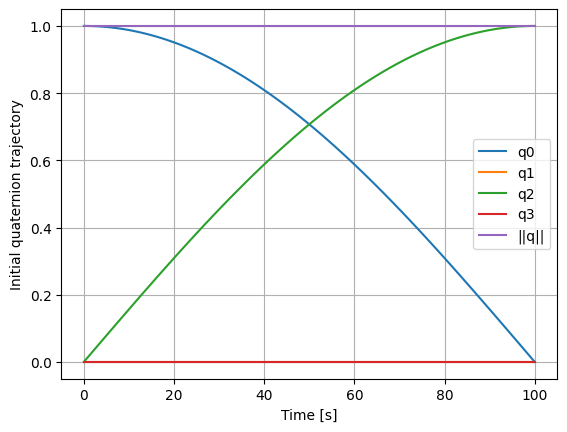

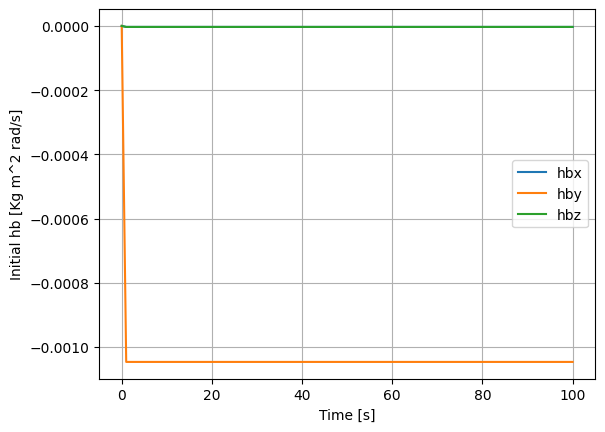

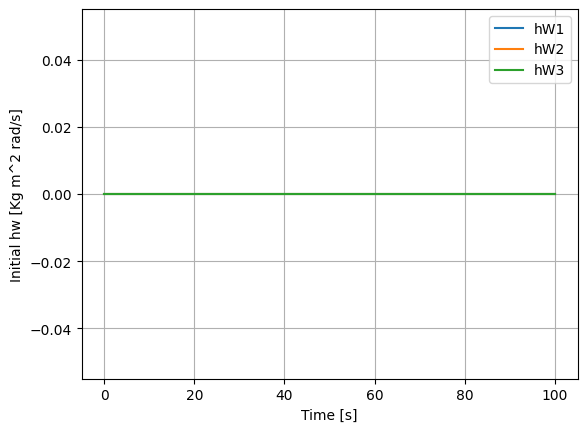

In [57]:
# Plot (scaled initial trajectories)

hu_value=np.copy(ohu_init)
hx_value=np.copy(ohx_init)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), hx_value[0,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), hx_value[1,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), hx_value[2,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), hx_value[3,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(hx_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Initial quaternion trajectory')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), hx_value[4,:], label='hbx')
plt.plot(np.linspace(0, tf, T+1), hx_value[5,:], label='hby')
plt.plot(np.linspace(0, tf, T+1), hx_value[6,:], label='hbz')
plt.ylabel('Initial hb [Kg m^2 rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.plot(np.linspace(0, tf, T+1), hx_value[7,:], label='hW1')
plt.plot(np.linspace(0, tf, T+1), hx_value[8,:], label='hW2')
plt.plot(np.linspace(0, tf, T+1), hx_value[9,:], label='hW3')
plt.ylabel('Initial hw [Kg m^2 rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

CVXpy Optimization problem (DPP compliant for cvxpygen)

In [ ]:
x = cp.Variable((states_size, T + 1), name='x')
u = cp.Variable((inputs_size, T), name='u')
vc = cp.Variable((states_size, T), name='vc')
if non_convex_inequalities_size>0:
    vi = cp.Variable((non_convex_inequalities_size, T+1), name='vi')

A_discrete = cp.Parameter((states_size,states_size*T), name='A_discrete')
B_discrete = cp.Parameter((states_size,inputs_size*T), name='B_discrete')
y_discrete = cp.Parameter((states_size,1*T), name='y_discrete')

if non_convex_inequalities_size>0:
    C_discrete = cp.Parameter((non_convex_inequalities_size,states_size*(T+1)), name='C_discrete')
    D_discrete = cp.Parameter((non_convex_inequalities_size,inputs_size*(T+1)), name='D_discrete')
    z_discrete = cp.Parameter((non_convex_inequalities_size,1*(T+1)), name='z_discrete')

tau = cp.Parameter(name='tau')
sqrt_tau = cp.Parameter(name='sqrt_tau')
sqrt_tau_xq_goal = cp.Parameter((4,1), name='sqrt_tau_xq_goal')

start_pos = cp.Parameter((states_size,1), name='start_pos')
end_pos = cp.Parameter((7,1), name='end_pos')

ox_cvxpy = cp.Parameter((states_size,T + 1), name='ox_cvxpy')
ou_cvxpy = cp.Parameter((inputs_size,T), name='ou_cvxpy')

S_x_scaling = cp.Parameter((states_size,states_size), name='S_x_scaling')
S_u_scaling = cp.Parameter((inputs_size,inputs_size), name='S_u_scaling')

c_x_scaling = cp.Parameter((states_size,1), name='c_x_scaling')
c_u_scaling = cp.Parameter((inputs_size,1), name='c_u_scaling')

inv_JW_S_W_scaling = cp.Parameter((3,3), name='inv_JW_S_W_scaling')
inv_JW_c_W_scaling = cp.Parameter((3,1), name='inv_JW_c_W_scaling')

inv_Jb_S_b_scaling = cp.Parameter((3,3), name='inv_Jb_S_b_scaling')
inv_Jb_c_b_scaling = cp.Parameter((3,1), name='inv_Jb_c_b_scaling')

lamb = cp.Parameter(name='lamb')
tau_lamb = cp.Parameter(name='tau_lamb')
etta = cp.Parameter(name='etta')

omegab_max = cp.Parameter(name='omegab_max')

torqW_max = cp.Parameter(name='torqW_max')
speedW_max = cp.Parameter(name='speedW_max')
Fth_max = cp.Parameter(name='Fth_max')

constraints = [
    x[0:10, 0:1] == start_pos[0:10,0:1],
    x[0:7, T:T+1] == end_pos[0:7,0:1]
]

cost = 0

for k in range(0, T):
    cost += cp.sum_squares(sqrt_tau*u[0:3,k:k+1])
    cost += 1.0*cp.norm(tau*u[3:7, k:k+1],1)
    #cost += 0.1*cp.sum_squares(sqrt_tau*u[3:7,k:k+1])
for k in range(0, T+1):
    cost += 1.0*cp.sum_squares(sqrt_tau*x[7:10,k:k+1])
    cost += 100*cp.sum_squares(sqrt_tau*x[0:4,k:k+1]-sqrt_tau_xq_goal)

for k in range(0, T):
    cost += cp.norm(tau_lamb*vc[0:states_size, k:k+1],1)

if non_convex_inequalities_size>0:
    for k in range(0, T+1):
        cost += cp.norm(tau_lamb*vi[0:non_convex_inequalities_size, k:k+1],1)

for k in range(0, T): # from 0 to T-1
    constraints += [x[0:states_size, k+1:k+2] == A_discrete[0:states_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + B_discrete[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+y_discrete[0:states_size, k:k+1]+vc[0:states_size, k:k+1]]

if non_convex_inequalities_size>0:
    for k in range(0, T): # from 0 to T-1
        constraints += [C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+z_discrete[0:non_convex_inequalities_size, k:k+1]<=vi[0:non_convex_inequalities_size, k:k+1]]
    constraints += [C_discrete[0:non_convex_inequalities_size,states_size*T:states_size*(T+1)] @ x[0:states_size, T:T+1] + D_discrete[0:non_convex_inequalities_size,inputs_size*T:inputs_size*(T+1)] @ u[0:inputs_size, T-1:T]+z_discrete[0:non_convex_inequalities_size, T:T+1]<=vi[0:non_convex_inequalities_size, T:T+1]]

for k in range(0, T): # from 0 to T-1
    constraints += [cp.norm(x[0:states_size, k:k+1]-ox_cvxpy[0:states_size,k:k+1],'inf')+cp.norm(u[0:inputs_size, k:k+1]-ou_cvxpy[0:inputs_size,k:k+1],'inf')<=etta]
constraints  += [cp.norm(x[0:states_size, T:T+1]-ox_cvxpy[0:states_size,T:T+1],'inf')+cp.norm(u[0:inputs_size, T-1:T]-ou_cvxpy[0:inputs_size,T-1:T],'inf')<=etta]

# Convex constraints
for k in range(0, T+1): # from 0 to T
    constraints += [cp.norm(inv_Jb_S_b_scaling@x[4:7,k:k+1]+inv_Jb_c_b_scaling, 'inf')<=omegab_max]
    constraints += [cp.norm(inv_JW_S_W_scaling@x[7:10,k:k+1]+inv_JW_c_W_scaling, 'inf')<=speedW_max]
    
for k in range(0, T): # from 0 to T-1
    constraints += [cp.norm(S_u_scaling[0:3,0:3]@u[0:3,k:k+1]+c_u_scaling[0:3,0:1], 'inf')<=torqW_max]

    for i in range(3, 7):
        constraints += [
            0 <= S_u_scaling[i:i+1, i:i+1] @ u[i:i+1, k:k+1] + c_u_scaling[i:i+1, 0:1],
            S_u_scaling[i:i+1, i:i+1] @ u[i:i+1, k:k+1] + c_u_scaling[i:i+1, 0:1] <= Fth_max
        ]

    constraints += [cp.norm(S_u_scaling[3:5,3:5]@u[3:5,k:k+1]+c_u_scaling[3:5,0:1], 1)<=Fth_max]
    constraints += [cp.norm(S_u_scaling[5:7,5:7]@u[5:7,k:k+1]+c_u_scaling[5:7,0:1], 1)<=Fth_max]

objective = cp.Minimize(cost)
problem = cp.Problem(objective, constraints)

COMPULSORY: The problem needs to be DPP compliant for CVXpygen

In [77]:
print("Is DPP? ", problem.is_dcp(dpp=True))

Is DPP?  True


In [78]:
aux_A_discrete = np.zeros((states_size,states_size*T))
aux_B_discrete = np.zeros((states_size,inputs_size*T))
aux_y_discrete = np.zeros((states_size,1*T))

aux_C_discrete = np.zeros((non_convex_inequalities_size,states_size*(T+1)))
aux_D_discrete = np.zeros((non_convex_inequalities_size,inputs_size*(T+1)))
aux_z_discrete = np.zeros((non_convex_inequalities_size,1*(T+1)))

In [79]:
def SCVx_scaling_x(x_no_scaled,inv_S_x_scaling_double,c_x_scaling_double):
    x_scaled = inv_S_x_scaling_double@(x_no_scaled-c_x_scaling_double)
    return x_scaled
    
def SCVx_scaling_u(u_no_scaled,inv_S_u_scaling_double,c_u_scaling_double):
    u_scaled = inv_S_u_scaling_double@(u_no_scaled-c_u_scaling_double)
    return u_scaled

def SCVx_inv_scaling_x(x_scaled,S_x_scaling_double,c_x_scaling_double):
    x_inv_scaling = S_x_scaling_double@x_scaled+c_x_scaling_double
    return x_inv_scaling
    
def SCVx_inv_scaling_u(u_scaled,S_u_scaling_double,c_u_scaling_double):
    u_inv_scaling = S_u_scaling_double@u_scaled+c_u_scaling_double
    return u_inv_scaling


def A_no_discrete_scaled_SCVx(A_no_discrete_no_scaled, inv_S_x_scaling_double,S_x_scaling_double):

    A_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@S_x_scaling_double

    return A_numeric

def B_no_discrete_scaled_SCVx(B_no_discrete_no_scaled, inv_S_x_scaling_double, S_u_scaling_double):

    B_numeric = inv_S_x_scaling_double@B_no_discrete_no_scaled@S_u_scaling_double

    return B_numeric

def y_no_discrete_scaled_SCVx(A_no_discrete_no_scaled,
                              B_no_discrete_no_scaled,
                              y_no_discrete_no_scaled,
                              inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double):

    y_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@c_x_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@B_no_discrete_no_scaled@c_u_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@y_no_discrete_no_scaled

    return y_numeric
    
def A_B_y_discrete_scaled(ohx, ohu, t0, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double, size_N):

    n = len(ohx)
    m = len(ohu)

    Phi = np.eye(n)
    G   = np.zeros((n, m))
    z   = np.zeros((n, 1))

    dt = tau_double / (size_N - 1)
    t  = t0

    for i in range(size_N - 1):

        # ===== k1 =====
        A1_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, t, dynamic_parameters_double)
        B1_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, t, dynamic_parameters_double)
        y1_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, t, dynamic_parameters_double)

        A1 = A_no_discrete_scaled_SCVx(A1_no, inv_S_x_scaling_double, S_x_scaling_double)
        B1 = B_no_discrete_scaled_SCVx(B1_no, inv_S_x_scaling_double, S_u_scaling_double)
        y1 = y_no_discrete_scaled_SCVx(A1_no, B1_no, y1_no,
                                       inv_S_x_scaling_double,
                                       c_x_scaling_double,
                                       c_u_scaling_double)

        k1_Phi = A1 @ Phi
        k1_G   = A1 @ G + B1
        k1_z   = A1 @ z + y1

        # ===== k2 =====
        t2 = t + 0.5*dt
        Phi2 = Phi + 0.5*dt*k1_Phi
        G2   = G   + 0.5*dt*k1_G
        z2   = z   + 0.5*dt*k1_z

        A2_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)
        B2_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)
        y2_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)

        A2 = A_no_discrete_scaled_SCVx(A2_no, inv_S_x_scaling_double, S_x_scaling_double)
        B2 = B_no_discrete_scaled_SCVx(B2_no, inv_S_x_scaling_double, S_u_scaling_double)
        y2 = y_no_discrete_scaled_SCVx(A2_no, B2_no, y2_no,
                                       inv_S_x_scaling_double,
                                       c_x_scaling_double,
                                       c_u_scaling_double)

        k2_Phi = A2 @ Phi2
        k2_G   = A2 @ G2 + B2
        k2_z   = A2 @ z2 + y2

        # ===== k3 =====
        Phi3 = Phi + 0.5*dt*k2_Phi
        G3   = G   + 0.5*dt*k2_G
        z3   = z   + 0.5*dt*k2_z

        A3_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)
        B3_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)
        y3_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, t2, dynamic_parameters_double)

        A3 = A_no_discrete_scaled_SCVx(A3_no, inv_S_x_scaling_double, S_x_scaling_double)
        B3 = B_no_discrete_scaled_SCVx(B3_no, inv_S_x_scaling_double, S_u_scaling_double)
        y3 = y_no_discrete_scaled_SCVx(A3_no, B3_no, y3_no,
                                       inv_S_x_scaling_double,
                                       c_x_scaling_double,
                                       c_u_scaling_double)

        k3_Phi = A3 @ Phi3
        k3_G   = A3 @ G3 + B3
        k3_z   = A3 @ z3 + y3

        # ===== k4 =====
        t4 = t + dt
        Phi4 = Phi + dt*k3_Phi
        G4   = G   + dt*k3_G
        z4   = z   + dt*k3_z

        A4_no = A_no_discrete_no_scaled_SCVx(ohx, ohu, t4, dynamic_parameters_double)
        B4_no = B_no_discrete_no_scaled_SCVx(ohx, ohu, t4, dynamic_parameters_double)
        y4_no = y_no_discrete_no_scaled_SCVx(ohx, ohu, t4, dynamic_parameters_double)

        A4 = A_no_discrete_scaled_SCVx(A4_no, inv_S_x_scaling_double, S_x_scaling_double)
        B4 = B_no_discrete_scaled_SCVx(B4_no, inv_S_x_scaling_double, S_u_scaling_double)
        y4 = y_no_discrete_scaled_SCVx(A4_no, B4_no, y4_no,
                                       inv_S_x_scaling_double,
                                       c_x_scaling_double,
                                       c_u_scaling_double)

        k4_Phi = A4 @ Phi4
        k4_G   = A4 @ G4 + B4
        k4_z   = A4 @ z4 + y4

        # ===== Update =====
        Phi += (dt/6)*(k1_Phi + 2*k2_Phi + 2*k3_Phi + k4_Phi)
        G   += (dt/6)*(k1_G   + 2*k2_G   + 2*k3_G   + k4_G)
        z   += (dt/6)*(k1_z   + 2*k2_z   + 2*k3_z   + k4_z)

        t += dt

    return Phi, G, z

def C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double):

    C_numeric = C_no_discrete_no_scaled@S_x_scaling_double

    return C_numeric

def D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double):

    D_numeric = D_no_discrete_no_scaled@S_u_scaling_double

    return D_numeric

def z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                              D_no_discrete_no_scaled,
                              z_no_discrete_no_scaled,
                              c_x_scaling_double, c_u_scaling_double):

    z_numeric = C_no_discrete_no_scaled@c_x_scaling_double
    z_numeric = z_numeric+D_no_discrete_no_scaled@c_u_scaling_double
    z_numeric = z_numeric+z_no_discrete_no_scaled

    return z_numeric

def C_D_z_discrete_scaled(ohx, ohu, t0, dynamic_parameters,
                           S_x_scaling_double, c_x_scaling_double,
                           S_u_scaling_double, c_u_scaling_double):
    

    C_no_discrete_no_scaled = C_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    C_no_discrete_scaled = C_no_discrete_scaled_SCVx(C_no_discrete_no_scaled, S_x_scaling_double)

    
    D_no_discrete_no_scaled = D_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    D_no_discrete_scaled = D_no_discrete_scaled_SCVx(D_no_discrete_no_scaled, S_u_scaling_double)

    z_no_discrete_no_scaled = z_no_discrete_no_scaled_SCVx(ohx, ohu, t0, dynamic_parameters)
    z_no_discrete_scaled = z_no_discrete_scaled_SCVx(C_no_discrete_no_scaled,
                                                     D_no_discrete_no_scaled,
                                                     z_no_discrete_no_scaled,
                                                     c_x_scaling_double, c_u_scaling_double)
    
    #Discretization no needed, bypass
    return C_no_discrete_scaled, D_no_discrete_scaled, z_no_discrete_scaled

def f_rk4_step(xk, uk, t, dt, dynamic_parameters,
               S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double):
    
    xk_no_scaled = SCVx_inv_scaling_x(xk,S_x_scaling_double,c_x_scaling_double)
    uk_no_scaled = SCVx_inv_scaling_u(uk,S_u_scaling_double,c_u_scaling_double)
    k1 = f_SCVx(xk_no_scaled, uk_no_scaled, t, dynamic_parameters)
    k2 = f_SCVx(xk_no_scaled + 0.5 * dt * k1, uk_no_scaled, t + 0.5*dt, dynamic_parameters)
    k3 = f_SCVx(xk_no_scaled + 0.5 * dt * k2, uk_no_scaled, t + 0.5*dt, dynamic_parameters)
    k4 = f_SCVx(xk_no_scaled + dt * k3, uk_no_scaled, t + dt, dynamic_parameters)
    return xk_no_scaled + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def f_Euler_step(xk, uk, t, dt, dynamic_parameters,
                 S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double):

    xk_no_scaled = SCVx_inv_scaling_x(xk,S_x_scaling_double,c_x_scaling_double)
    uk_no_scaled = SCVx_inv_scaling_u(uk,S_u_scaling_double,c_u_scaling_double)

    return xk_no_scaled + dt * f_SCVx(xk_no_scaled, uk_no_scaled, t, dynamic_parameters)


Modify the SCVx cost function according to user requirements:

In [80]:
def J_SCVx(x,u,T,tau_double, dynamic_parameters, xq_goal_double,
           S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double):
    
    cost = 0
    for k in range(0, T): # from 0 to T-1
        cost += tau_double*np.linalg.norm(u[0:3,k:k+1], ord=2)**2
        cost += 1*tau_double*np.linalg.norm(u[3:7,k:k+1], ord=1)
    for k in range(0, T+1):
        cost += 1*tau_double*np.linalg.norm(x[7:10,k:k+1], ord=2)**2
        cost += 100*tau_double*np.linalg.norm(x[0:4,k:k+1]-xq_goal_double, ord=2)**2

    for k in range(0, T): # from 0 to T-1

        flow_map = f_rk4_step(x[0:, k:k+1], u[:, k:k+1], k/T*tf, tau_double, dynamic_parameters,
        S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)

        SCVx_defect = SCVx_inv_scaling_x(x[:, k+1:k+2],S_x_scaling_double,c_x_scaling_double)-flow_map

        cost += tau_double*np.linalg.norm(lamb_double*SCVx_defect, ord=1)

    for k in range(0, T+1): # from 0 to T
        x_no_scaled = SCVx_inv_scaling_x(x[:,k:k+1],S_x_scaling_double,c_x_scaling_double)
        if k == T:
            u_no_scaled = SCVx_inv_scaling_u(u[:,T-1:T],S_u_scaling_double,c_u_scaling_double)
        else:
            u_no_scaled = SCVx_inv_scaling_u(u[:,k:k+1],S_u_scaling_double,c_u_scaling_double)
        if non_convex_inequalities_size>0:    
            g_double = g_SCVx(x_no_scaled, u_no_scaled, k/T*tf, dynamic_parameters_double)

            for i in range(0,np.size(g_double)):
                cost += tau_double*np.abs(lamb_double*(np.max([g_double[i,0],0])))

    return cost

In [81]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T))
etta_double = np.copy(etta_double_init)

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = SCVx_scaling_x(ohx[0:states_size,t:t+1],inv_S_x_scaling_double,c_x_scaling_double)

for t in range(0, T):
    ou[0:inputs_size,t:t+1] = SCVx_scaling_u(ohu[0:inputs_size,t:t+1],inv_S_u_scaling_double,c_u_scaling_double)

ox_cvxpy.value=ox #trajectory initialization (already scaled)
ou_cvxpy.value=ou #trajectory initialization (already scaled)

tau.value = tau_double
sqrt_tau.value = (tau_double)**0.5

lamb.value = lamb_double

tau_lamb.value = tau_double*lamb_double
etta.value = etta_double

S_x_scaling.value = S_x_scaling_double
S_u_scaling.value = S_u_scaling_double

c_x_scaling.value = c_x_scaling_double
c_u_scaling.value = c_u_scaling_double

omegab_max.value = omegab_max_double
torqW_max.value = torqW_max_double
speedW_max.value = speedW_max_double
Fth_max.value = Fth_max_double

start_pos.value = SCVx_scaling_x(start_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
end_pos_aux = SCVx_scaling_x(np.block([[end_pos_double],[0],[0],[0]]),inv_S_x_scaling_double,c_x_scaling_double)
end_pos.value = end_pos_aux[0:7,0:1]

sqrt_tau_xq_goal_double = (tau_double)**0.5*end_pos_aux[0:4,0:1]
xq_goal_double = np.copy(end_pos_aux[0:4,0:1])
sqrt_tau_xq_goal.value = np.copy(sqrt_tau_xq_goal_double)

inv_Jb_S_b_scaling.value = np.linalg.inv(Jsat_double)@S_x_scaling_double[4:7,4:7]
inv_Jb_c_b_scaling.value = np.linalg.inv(Jsat_double)@c_x_scaling_double[4:7,0:1]

inv_JW_S_W_scaling.value = np.linalg.inv(IWmatrix_double)@S_x_scaling_double[7:10,7:10]
inv_JW_c_W_scaling.value = np.linalg.inv(IWmatrix_double)@c_x_scaling_double[7:10,0:1]

t0 = time.time()

i=1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):


    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = SCVx_inv_scaling_x(ox[0:states_size,t:t+1],S_x_scaling_double,c_x_scaling_double)

    for t in range(0, T):
        ohu[0:inputs_size,t:t+1] = SCVx_inv_scaling_u(ou[0:inputs_size,t:t+1],S_u_scaling_double,c_u_scaling_double)

    t0aux = time.time()
    
    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete, aux_aux_y_discrete = A_B_y_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double, size_N)

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        
        aux_B_discrete[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete)
        
        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)

    if non_convex_inequalities_size>0:
      for k in range(0, T+1):
          aux_aux_C_discrete, aux_aux_D_discrete, aux_aux_z_discrete = C_D_z_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double,
                  S_x_scaling_double, c_x_scaling_double,
                  S_u_scaling_double, c_u_scaling_double)
          
          aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
        
          aux_D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_D_discrete)
          
          aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ",(t1aux-t0aux)*1000)

    A_discrete.value = np.copy(aux_A_discrete)
    B_discrete.value = np.copy(aux_B_discrete)
    y_discrete.value = np.copy(aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      C_discrete.value = np.copy(aux_C_discrete)
      D_discrete.value = np.copy(aux_D_discrete)
      z_discrete.value = np.copy(aux_z_discrete)

    t0aux = time.time()
    val=problem.solve(solver='ECOS',ignore_dpp=True) #IF YOU USE CVXPYGEN: ignore_dpp=False
    t1aux = time.time()

    print("Solver time [ms]: ",(t1aux-t0aux)*1000)

    vc_opt=np.copy(vc.value)
    if non_convex_inequalities_size>0:
      vi_opt=np.copy(vi.value)
    x_opt=np.copy(x.value)
    u_opt=np.copy(u.value)

    L_SCVx_opt=val

    J_SCVx_opt=J_SCVx(x_opt,u_opt,T,tau_double, dynamic_parameters_double, xq_goal_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)
    oJ_SCVx=J_SCVx(ox,ou,T,tau_double, dynamic_parameters_double, xq_goal_double,
                      S_x_scaling_double,c_x_scaling_double,S_u_scaling_double,c_u_scaling_double)
    
    print("Iteration number: ",i," Etta: ",etta.value, " Rho: ",rho_i)
    print("L_SCVx_opt: "+str(val)+" J_SCVx_opt: "+str(J_SCVx_opt)+" oJ_SCVx: "+str(oJ_SCVx)+" Norm_x_diff: "+str(np.max(np.linalg.norm((x_opt-ox), ord=2,axis=0))),"\n")
    
    
    Delta_J_SCVx=oJ_SCVx-J_SCVx_opt
    #Delta_L_SCVx=J_SCVx_opt-L_SCVx_opt
    Delta_L_SCVx=oJ_SCVx-L_SCVx_opt

    if (Delta_L_SCVx<e_tol*np.abs(oJ_SCVx) or np.max(np.linalg.norm((x_opt-ox), ord=1,axis=0))<epsilon_stop_norm) and no_first_iterations:
      x_global=np.copy(ox)
      u_global=np.copy(ou)
      print("Maximum iterations unreached! :)")
      break;
    else:
      rho_i=Delta_J_SCVx/Delta_L_SCVx
      if rho_i<rho0:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(ox)
        ou=np.copy(ou)
      if rho_i>=rho0 and rho_i<rho1:
        etta.value=max([etta0,etta.value/beta_sh])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho1 and rho_i<rho2:
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)
      if rho_i>=rho2:
        etta.value=min([etta1,beta_gr*etta.value])
        ox=np.copy(x_opt)
        ou=np.copy(u_opt)

    ox_cvxpy.value=np.copy(ox)
    ou_cvxpy.value=np.copy(ou)


    if i==3:
        no_first_iterations = True
    i=i+1
    
t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  1862.2887134552002
Solver time [ms]:  3239.8788928985596
Iteration number:  1  Etta:  1.0  Rho:  None
L_SCVx_opt: 2196.585869064025 J_SCVx_opt: 4170.313048034263 oJ_SCVx: 22121.31284335761 Norm_x_diff: 0.32103726577226666 

Discretization time [ms]:  1817.2526359558105
Solver time [ms]:  2927.720546722412
Iteration number:  2  Etta:  2.0  Rho:  0.9009408168294253
L_SCVx_opt: 1387.0879981219446 J_SCVx_opt: 6657.629199141362 oJ_SCVx: 4170.313048034263 Norm_x_diff: 0.5243406551088129 

Discretization time [ms]:  1809.1850280761719
Solver time [ms]:  3093.684673309326
Iteration number:  3  Etta:  1.0  Rho:  -0.8936812893321212
L_SCVx_opt: 1451.5500371543094 J_SCVx_opt: 6259.066777768347 oJ_SCVx: 4170.313048034263 Norm_x_diff: 0.4507345942467901 

Discretization time [ms]:  1859.6735000610352
Solver time [ms]:  2993.8251972198486
Iteration number:  4  Etta:  0.5  Rho:  -0.7682735572667799
L_SCVx_opt: 1558.01490192024 J_SCVx_opt: 5609.570416861325 oJ_SCVx: 4170.313

In [82]:
print("||v_c||_1 (non linear model accuracy) = ",np.linalg.norm((vc.value[:, :]), ord=1))
if non_convex_inequalities_size>0:
    print("||v_i||_i (non convex constraints accuracy) = ",np.linalg.norm((vi.value[:, :]), ord=1))

||v_c||_1 (non linear model accuracy) =  3.4265536600302563e-10


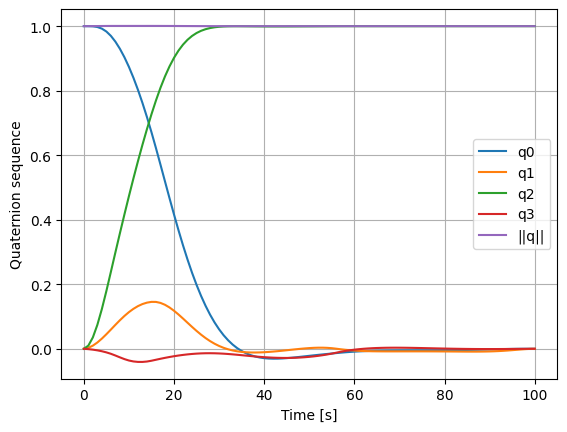

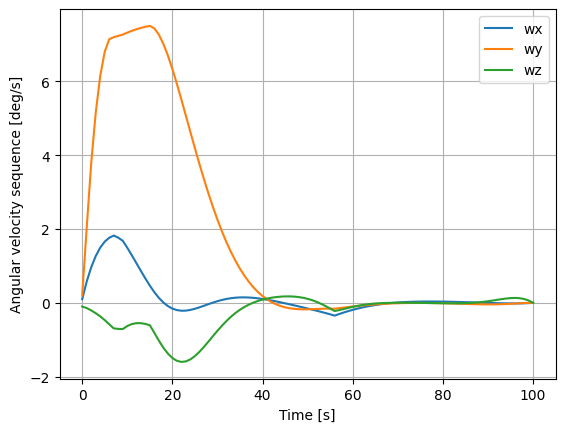

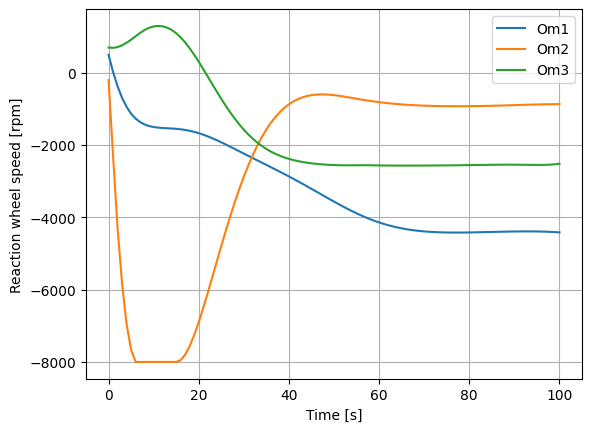

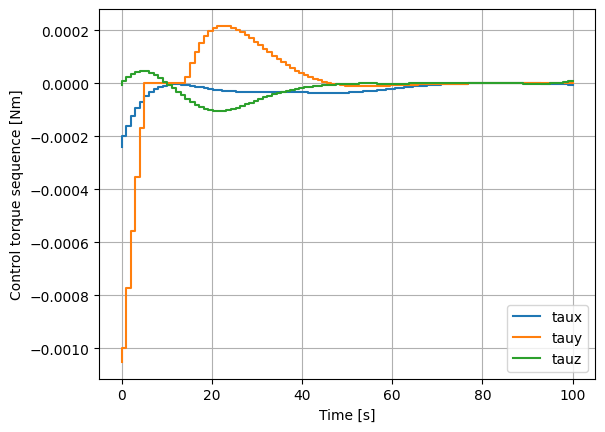

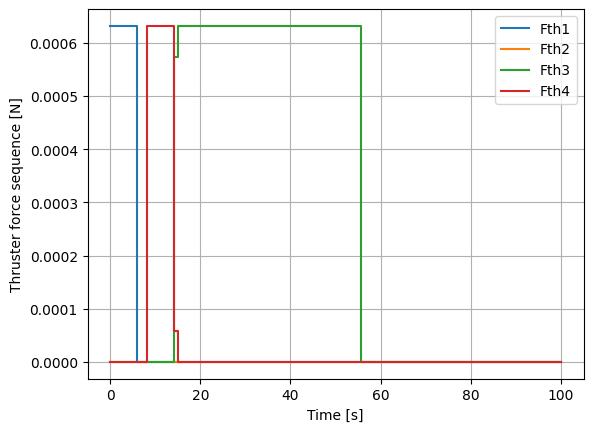

In [83]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x

#Uncomment if there is no optimal solution (or keyboard interruption)

x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T)

for i in range(0,T+1):
    x_value[4:7,i:i+1] = np.linalg.inv(Jsat_double)@x_value[4:7,i:i+1]*180/np.pi

for i in range(0,T+1):
    x_value[7:10,i:i+1] = np.linalg.inv(IWmatrix_double)@x_value[7:10,i:i+1]*60/(2*np.pi)

#x_value=global_inv_scaling(np.copy(x_global),S_x_scaling_double,c_x_scaling_double,T+1)
#u_value=global_inv_scaling(np.copy(u_global),S_u_scaling_double,c_u_scaling_double,T)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), x_value[0,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), x_value[1,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), x_value[2,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), x_value[3,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), x_value[4,:], label='wx')
plt.plot(np.linspace(0, tf, T+1), x_value[5,:], label='wy')
plt.plot(np.linspace(0, tf, T+1), x_value[6,:], label='wz')

plt.ylabel('Angular velocity sequence [deg/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.plot(np.linspace(0, tf, T+1), x_value[7,:], label='Om1')
plt.plot(np.linspace(0, tf, T+1), x_value[8,:], label='Om2')
plt.plot(np.linspace(0, tf, T+1), x_value[9,:], label='Om3')

plt.ylabel('Reaction wheel speed [rpm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(5)
plt.step(np.linspace(0, tf, T), u_value[0,:], label='taux')
plt.step(np.linspace(0, tf, T), u_value[1,:], label='tauy')
plt.step(np.linspace(0, tf, T), u_value[2,:], label='tauz')

plt.ylabel('Control torque sequence [Nm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(6)
plt.step(np.linspace(0, tf, T), u_value[3,:], label='Fth1')
plt.step(np.linspace(0, tf, T), u_value[4,:], label='Fth2')
plt.step(np.linspace(0, tf, T), u_value[5,:], label='Fth3')
plt.step(np.linspace(0, tf, T), u_value[6,:], label='Fth4')

plt.ylabel('Thruster force sequence [N]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


In [85]:
print(np.sum(u_value[4:5,:],axis=0))

[4.32613624e-12 4.14081128e-12 4.15587562e-12 4.32552171e-12
 4.60541045e-12 4.95584888e-12 5.33580894e-12 5.70461300e-12
 6.03911767e-12 6.33839791e-12 6.61069918e-12 6.86791271e-12
 7.12103130e-12 7.37578867e-12 7.63258348e-12 7.88723340e-12
 8.12395789e-12 8.31661812e-12 8.44463551e-12 8.49720099e-12
 8.47292635e-12 8.37859415e-12 8.22696067e-12 8.03415364e-12
 7.81717388e-12 7.59186540e-12 7.37153882e-12 7.16627235e-12
 6.98279271e-12 6.82477208e-12 6.69336895e-12 6.58786198e-12
 6.50626374e-12 6.44585665e-12 6.40361245e-12 6.37650067e-12
 6.36169112e-12 6.35667365e-12 6.35931206e-12 6.36785318e-12
 6.38090362e-12 6.39738956e-12 6.41650556e-12 6.43766008e-12
 6.46042031e-12 6.48445924e-12 6.50950626e-12 6.53530225e-12
 6.56155870e-12 6.58792357e-12 6.61395504e-12 6.63910452e-12
 6.66271378e-12 6.68402779e-12 6.70222894e-12 6.71649281e-12
 6.72607250e-12 6.73506791e-12 6.74714028e-12 6.76140339e-12
 6.77698739e-12 6.79308812e-12 6.80899781e-12 6.82412156e-12
 6.83798255e-12 6.850219

# CVXpygen

In [81]:
from cvxpygen import cpg
cpg.generate_code(problem, code_dir='BIRDS_TM_RW_ECOS_T71_l2_q',solver='ECOS')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Generating code with CVXPYgen ...


KeyboardInterrupt: 

In [ ]:
from BIRDS_TM_RW_ECOS_T71_l2_q.cpg_solver import cpg_solve #CHANGE
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt

with open('BIRDS_TM_RW_ECOS_T71_l2_q/problem.pickle', 'rb') as file: #CHANGE
    problem = pickle.load(file)

problem.register_solve('cpg', cpg_solve)

In [ ]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T))
etta_double = np.copy(etta_double_init)

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = SCVx_scaling_x(
        ohx[0:states_size,t:t+1],
        inv_S_x_scaling_double,
        c_x_scaling_double
    )

for t in range(0, T):
    ou[0:inputs_size,t:t+1] = SCVx_scaling_u(
        ohu[0:inputs_size,t:t+1],
        inv_S_u_scaling_double,
        c_u_scaling_double
    )

# ---- PARAMETER ASSIGNMENTS ----

problem.param_dict['ox_cvxpy'].value = ox
problem.param_dict['ou_cvxpy'].value = ou

#problem.param_dict['tau'].value = tau_double
problem.param_dict['sqrt_tau'].value = (tau_double)**0.5

#problem.param_dict['lamb'].value = lamb_double
problem.param_dict['tau_lamb'].value = tau_double*lamb_double
problem.param_dict['etta'].value = etta_double

#problem.param_dict['S_x_scaling'].value = S_x_scaling_double
problem.param_dict['S_u_scaling'].value = S_u_scaling_double

#problem.param_dict['c_x_scaling'].value = c_x_scaling_double
problem.param_dict['c_u_scaling'].value = c_u_scaling_double

problem.param_dict['omegab_max'].value = omegab_max_double
problem.param_dict['torqW_max'].value = torqW_max_double
problem.param_dict['speedW_max'].value = speedW_max_double

problem.param_dict['start_pos'].value = SCVx_scaling_x(
    start_pos_double,
    inv_S_x_scaling_double,
    c_x_scaling_double
)

end_pos_aux = SCVx_scaling_x(
    np.block([[end_pos_double],[0],[0],[0]]),
    inv_S_x_scaling_double,
    c_x_scaling_double
)

problem.param_dict['end_pos'].value = end_pos_aux[0:7,0:1]

sqrt_tau_xq_goal_double = (tau_double)**0.5 * end_pos_aux[0:4,0:1]
xq_goal_double = np.copy(end_pos_aux[0:4,0:1])

problem.param_dict['sqrt_tau_xq_goal'].value = np.copy(sqrt_tau_xq_goal_double)

problem.param_dict['inv_Jb_S_b_scaling'].value = (
    np.linalg.inv(Jsat_double) @ S_x_scaling_double[4:7,4:7]
)

problem.param_dict['inv_Jb_c_b_scaling'].value = (
    np.linalg.inv(Jsat_double) @ c_x_scaling_double[4:7,0:1]
)

problem.param_dict['inv_JW_S_W_scaling'].value = (
    np.linalg.inv(IWmatrix_double) @ S_x_scaling_double[7:10,7:10]
)

problem.param_dict['inv_JW_c_W_scaling'].value = (
    np.linalg.inv(IWmatrix_double) @ c_x_scaling_double[7:10,0:1]
)

# ---- SCVX LOOP ----

t0 = time.time()

i = 1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):

    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = SCVx_inv_scaling_x(
            ox[0:states_size,t:t+1],
            S_x_scaling_double,
            c_x_scaling_double
        )

    for t in range(0, T):
        ohu[0:inputs_size,t:t+1] = SCVx_inv_scaling_u(
            ou[0:inputs_size,t:t+1],
            S_u_scaling_double,
            c_u_scaling_double
        )

    t0aux = time.time()

    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete, aux_aux_y_discrete = A_B_y_discrete_scaled(
            ohx[0:states_size,k:k+1],
            ohu[0:inputs_size,k:k+1],
            k/T*tf,
            dynamic_parameters_double,
            tau_double,
            S_x_scaling_double,
            inv_S_x_scaling_double,
            c_x_scaling_double,
            S_u_scaling_double,
            inv_S_u_scaling_double,
            c_u_scaling_double,
            size_N
        )

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        aux_B_discrete[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete)
        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)

    if non_convex_inequalities_size > 0:
        for k in range(0, T+1):
            aux_aux_C_discrete, aux_aux_D_discrete, aux_aux_z_discrete = C_D_z_discrete_scaled(
                ohx[0:states_size,k:k+1],
                ohu[0:inputs_size,k:k+1],
                k/T*tf,
                dynamic_parameters_double,
                S_x_scaling_double,
                c_x_scaling_double,
                S_u_scaling_double,
                c_u_scaling_double
            )

            aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
            aux_D_discrete[0:non_convex_inequalities_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_D_discrete)
            aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ", (t1aux-t0aux)*1000)

    problem.param_dict['A_discrete'].value = np.copy(aux_A_discrete)
    problem.param_dict['B_discrete'].value = np.copy(aux_B_discrete)
    problem.param_dict['y_discrete'].value = np.copy(aux_y_discrete)

    if non_convex_inequalities_size > 0:
        problem.param_dict['C_discrete'].value = np.copy(aux_C_discrete)
        problem.param_dict['D_discrete'].value = np.copy(aux_D_discrete)
        problem.param_dict['z_discrete'].value = np.copy(aux_z_discrete)

    t0aux = time.time()
    val = problem.solve(method='cpg')
    t1aux = time.time()

    print("Solver time [ms]: ", (t1aux-t0aux)*1000)

    vc_opt = np.copy(problem.var_dict['vc'].value)
    if non_convex_inequalities_size > 0:
        vi_opt = np.copy(problem.var_dict['vi'].value)
    x_opt = np.copy(problem.var_dict['x'].value)
    u_opt = np.copy(problem.var_dict['u'].value)

    L_SCVx_opt = val

    J_SCVx_opt = J_SCVx(
        x_opt, u_opt, T, tau_double,
        dynamic_parameters_double,
        xq_goal_double,
        S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, c_u_scaling_double
    )

    oJ_SCVx = J_SCVx(
        ox, ou, T, tau_double,
        dynamic_parameters_double,
        xq_goal_double,
        S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, c_u_scaling_double
    )

    print("Iteration number: ",i," Etta: ",problem.param_dict['etta'].value, " Rho: ",rho_i)
    print("L_SCVx_opt: "+str(val)+" J_SCVx_opt: "+str(J_SCVx_opt)+" oJ_SCVx: "+str(oJ_SCVx)+" Norm_x_diff: "+str(np.max(np.linalg.norm((x_opt-ox), ord=2,axis=0))),"\n")

    Delta_J_SCVx = oJ_SCVx - J_SCVx_opt
    Delta_L_SCVx = oJ_SCVx - L_SCVx_opt

    if ((Delta_L_SCVx < e_tol*np.abs(oJ_SCVx) or
         np.max(np.linalg.norm((x_opt-ox), ord=1, axis=0)) < epsilon_stop_norm)
        and no_first_iterations):

        x_global = np.copy(ox)
        u_global = np.copy(ou)
        print("COGU has converged! :)")
        break

    else:
        rho_i = Delta_J_SCVx / Delta_L_SCVx

        if rho_i < rho0:
            problem.param_dict['etta'].value = max([etta0, problem.param_dict['etta'].value / beta_sh])

        if rho_i >= rho0 and rho_i < rho1:
            problem.param_dict['etta'].value = max([etta0, problem.param_dict['etta'].value / beta_sh])
            ox = np.copy(x_opt)
            ou = np.copy(u_opt)

        if rho_i >= rho1 and rho_i < rho2:
            ox = np.copy(x_opt)
            ou = np.copy(u_opt)

        if rho_i >= rho2:
            problem.param_dict['etta'].value = min([etta1, beta_gr * problem.param_dict['etta'].value])
            ox = np.copy(x_opt)
            ou = np.copy(u_opt)

    problem.param_dict['ox_cvxpy'].value = np.copy(ox)
    problem.param_dict['ou_cvxpy'].value = np.copy(ou)

    if i == 3:
        no_first_iterations = True

    i += 1

t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  1273.2055187225342
Solver time [ms]:  47.63627052307129
Iteration number:  1  Etta:  1.0  Rho:  None
L_SCVx_opt: 890.2879770160139 J_SCVx_opt: 2767.7573851731304 oJ_SCVx: 12258.317071256028 Norm_x_diff: 0.2977146985912076 

Discretization time [ms]:  1254.2011737823486
Solver time [ms]:  44.72923278808594
Iteration number:  2  Etta:  2.0  Rho:  0.834846533854457
L_SCVx_opt: 540.4582704764097 J_SCVx_opt: 3716.889297506459 oJ_SCVx: 2767.7573851731304 Norm_x_diff: 0.556038499741064 

Discretization time [ms]:  1316.8606758117676
Solver time [ms]:  38.683176040649414
Iteration number:  3  Etta:  1.0  Rho:  -0.4261358099909122
L_SCVx_opt: 548.2524123428765 J_SCVx_opt: 3588.769285640172 oJ_SCVx: 2767.7573851731304 Norm_x_diff: 0.5097450794380298 

Discretization time [ms]:  1270.2271938323975
Solver time [ms]:  51.526546478271484
Iteration number:  4  Etta:  0.5  Rho:  -0.3699076643293612
L_SCVx_opt: 571.9498726729797 J_SCVx_opt: 3596.7901948090885 oJ_SCVx: 2767.75

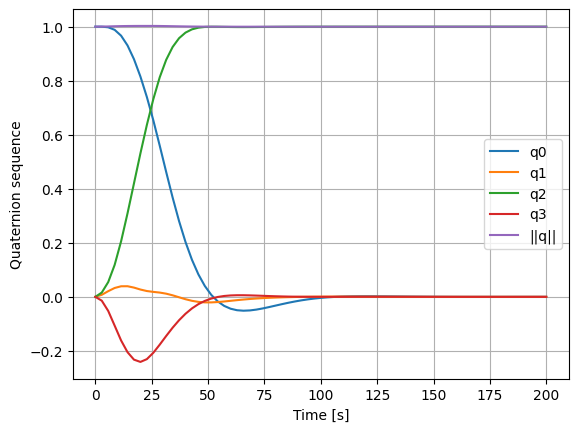

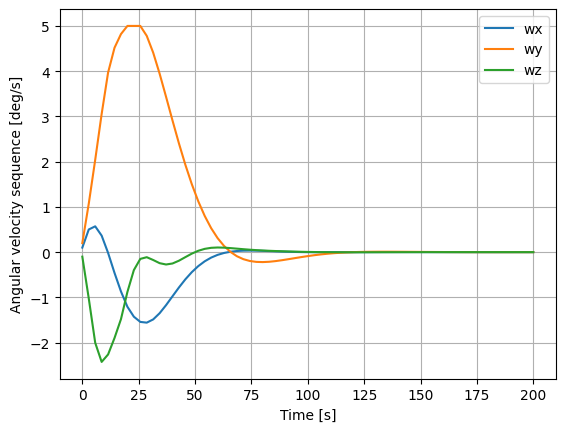

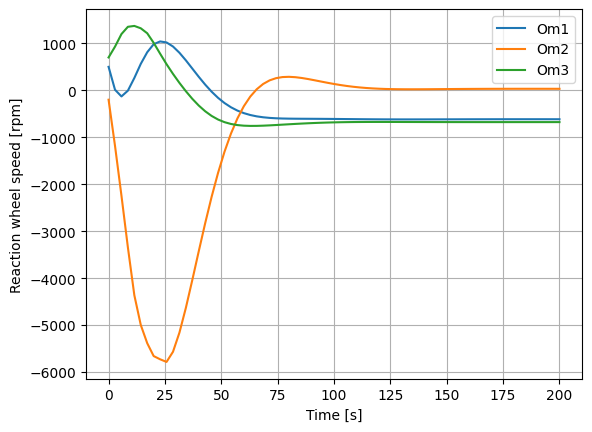

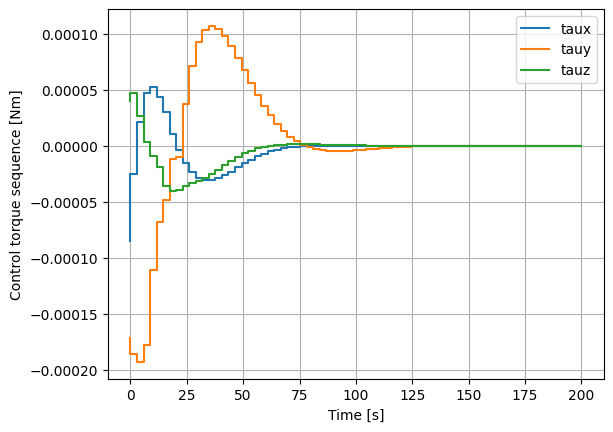

In [ ]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x

#Uncomment if there is no optimal solution (or keyboard interruption)

x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T)

for i in range(0,T+1):
    x_value[4:7,i:i+1] = np.linalg.inv(Jsat_double)@x_value[4:7,i:i+1]*180/np.pi

for i in range(0,T+1):
    x_value[7:10,i:i+1] = np.linalg.inv(IWmatrix_double)@x_value[7:10,i:i+1]*60/(2*np.pi)

#x_value=global_inv_scaling(np.copy(x_global),S_x_scaling_double,c_x_scaling_double,T+1)
#u_value=global_inv_scaling(np.copy(u_global),S_u_scaling_double,c_u_scaling_double,T)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), x_value[0,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), x_value[1,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), x_value[2,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), x_value[3,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[0:4,:],axis=0), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), x_value[4,:], label='wx')
plt.plot(np.linspace(0, tf, T+1), x_value[5,:], label='wy')
plt.plot(np.linspace(0, tf, T+1), x_value[6,:], label='wz')

plt.ylabel('Angular velocity sequence [deg/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.plot(np.linspace(0, tf, T+1), x_value[7,:], label='Om1')
plt.plot(np.linspace(0, tf, T+1), x_value[8,:], label='Om2')
plt.plot(np.linspace(0, tf, T+1), x_value[9,:], label='Om3')

plt.ylabel('Reaction wheel speed [rpm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(5)
plt.step(np.linspace(0, tf, T), u_value[0,:], label='taux')
plt.step(np.linspace(0, tf, T), u_value[1,:], label='tauy')
plt.step(np.linspace(0, tf, T), u_value[2,:], label='tauz')

plt.ylabel('Control torque sequence [Nm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

Execute the following code to copy and paste the most important .c and .h inside the folder "BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy".

In [ ]:
import os
import shutil
import re

def collect_files(source_folder):
    # Define the destination folder
    destination_folder = os.path.join(source_folder, 'matlab_copy')
    
    # Create the destination folder if it doesn't exist
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    
    # Files to delete
    files_to_delete = ['runecos_exp.c', 'runecos.c','CMakeCCompilerId.c']
    
    # Files in which to replace 'pinv' with 'pinv2'
    files_to_replace = ['splamm.h', 'splamm.c', 'preproc.c']
    
    # Files to modify by removing "../../include/"
    files_to_modify = ['ldl.h', 'ldl.c']

    # Walk through the source folder and its subfolders
    for root, dirs, files in os.walk(source_folder):
        # Skip the destination folder
        if root == destination_folder:
            continue
        
        for file in files:
            file_path = os.path.join(root, file)
            
            if file.endswith('.c') or file.endswith('.h'):
                # Copy the file to the destination folder
                shutil.copy(file_path, destination_folder)
                print(f"Copied {file_path} to {destination_folder}")

    # After all files are copied, process the files in the destination folder
    for file in os.listdir(destination_folder):
        file_path = os.path.join(destination_folder, file)
        
        # Delete the specified files
        if file in files_to_delete:
            os.remove(file_path)
            print(f"Deleted {file_path}")
            continue
        
        # Modify ldl.h and ldl.c files to remove "../../include/"
        if file in files_to_modify:
            with open(file_path, 'r') as f:
                content = f.read()
            content = content.replace('../../include/', '')
            with open(file_path, 'w') as f:
                f.write(content)
            print(f"Modified {file} to remove '../../include/'")
        
        # Replace 'pinv' function calls with 'pinv2' in specified files
        if file in files_to_replace:
            with open(file_path, 'r') as f:
                content = f.read()
            content = re.sub(r'\bpinv\b\s*\(', 'pinv2(', content)
            with open(file_path, 'w') as f:
                f.write(content)
            print(f"Replaced 'pinv' function calls with 'pinv2' in {file}")

# Usage example
source_folder = 'BIRDS_TM_RW_ECOS_T71_l2_q'
collect_files(source_folder)

Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\build\CMakeFiles\4.2.1\CompilerIdC\CMakeCCompilerId.c to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\include\cpg_solve.h to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\include\cpg_workspace.h to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\ecos_bb\ecos_bb.c to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\ecos_bb\ecos_bb_preproc.c to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\external\amd\include\amd.h to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\external\amd\include\amd_internal.h to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\external\amd\src\amd_1.c to BIRDS_TM_RW_ECOS_T71_l2_q\matlab_copy
Copied BIRDS_TM_RW_ECOS_T71_l2_q\c\solver_code\external\amd\src\amd_2.c to BIRDS_TM_RW_ECOS_T71_l2_q\m